In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import  LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor


from sklearn.metrics import r2_score, mean_squared_error

import warnings
warnings.filterwarnings('ignore')


dataset = pd.read_csv('..\data\car_price_prediction.csv')
df= dataset.copy()
df.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  str    
 3   Manufacturer      19237 non-null  str    
 4   Model             19237 non-null  str    
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  str    
 7   Leather interior  19237 non-null  str    
 8   Fuel type         19237 non-null  str    
 9   Engine volume     19237 non-null  str    
 10  Mileage           19237 non-null  str    
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  str    
 13  Drive wheels      19237 non-null  str    
 14  Doors             19237 non-null  str    
 15  Wheel             19237 non-null  str    
 16  Color             19237 non-null  str    
 17  Airb

In [3]:
df.shape

(19237, 18)

In [4]:
df.describe()


,ID,Price,Prod. year,Cylinders,Airbags
count,1.923700e+04,1.923700e+04,19237.000000,19237.000000,19237.000000
mean,4.557654e+07,1.855593e+04,2010.912824,4.582991,6.582627
std,9.365914e+05,1.905813e+05,5.668673,1.199933,4.320168
min,2.074688e+07,1.000000e+00,1939.000000,1.000000,0.000000
25%,4.569837e+07,5.331000e+03,2009.000000,4.000000,4.000000
50%,4.577231e+07,1.317200e+04,2012.000000,4.000000,6.000000
75%,4.580204e+07,2.207500e+04,2015.000000,4.000000,12.000000
max,4.581665e+07,2.630750e+07,2020.000000,16.000000,16.000000


In [5]:
df.duplicated().sum()


np.int64(313)

In [6]:
df.isnull().sum()

ID                  0
Price               0
Levy                0
Manufacturer        0
Model               0
Prod. year          0
Category            0
Leather interior    0
Fuel type           0
Engine volume       0
Mileage             0
Cylinders           0
Gear box type       0
Drive wheels        0
Doors               0
Wheel               0
Color               0
Airbags             0
dtype: int64

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
# ------------------------------ Analysis ------------------------------------------------

df['Manufacturer'].unique()


<StringArray>
[        'LEXUS',     'CHEVROLET',         'HONDA',          'FORD',
       'HYUNDAI',        'TOYOTA', 'MERCEDES-BENZ',          'OPEL',
       'PORSCHE',           'BMW',          'JEEP',    'VOLKSWAGEN',
          'AUDI',       'RENAULT',        'NISSAN',        'SUBARU',
        'DAEWOO',           'KIA',    'MITSUBISHI',     'SSANGYONG',
         'MAZDA',           'GMC',          'FIAT',      'INFINITI',
    'ALFA ROMEO',        'SUZUKI',         'ACURA',       'LINCOLN',
           'VAZ',           'GAZ',       'CITROEN',    'LAND ROVER',
          'MINI',         'DODGE',      'CHRYSLER',        'JAGUAR',
         'ISUZU',         'SKODA',      'DAIHATSU',         'BUICK',
         'TESLA',      'CADILLAC',       'PEUGEOT',       'BENTLEY',
         'VOLVO',          'სხვა',         'HAVAL',        'HUMMER',
         'SCION',           'UAZ',       'MERCURY',           'ZAZ',
         'ROVER',          'SEAT',        'LANCIA',      'MOSKVICH',
      'MASERATI',   

In [10]:
df['Category'].unique()


<StringArray>
[       'Jeep',   'Hatchback',       'Sedan',    'Microbus', 'Goods wagon',
   'Universal',       'Coupe',     'Minivan',   'Cabriolet',   'Limousine',
      'Pickup']
Length: 11, dtype: str

In [11]:
df['Leather interior'].unique()


<StringArray>
['Yes', 'No']
Length: 2, dtype: str

In [12]:
df['Fuel type'].unique()


<StringArray>
['Hybrid', 'Petrol', 'Diesel', 'CNG', 'Plug-in Hybrid', 'LPG', 'Hydrogen']
Length: 7, dtype: str

In [13]:
for i in df.columns:
    print(i, ':', df[i].nunique())

ID : 18924
Price : 2315
Levy : 559
Manufacturer : 65
Model : 1590
Prod. year : 54
Category : 11
Leather interior : 2
Fuel type : 7
Engine volume : 107
Mileage : 7687
Cylinders : 13
Gear box type : 4
Drive wheels : 3
Doors : 3
Wheel : 2
Color : 16
Airbags : 17


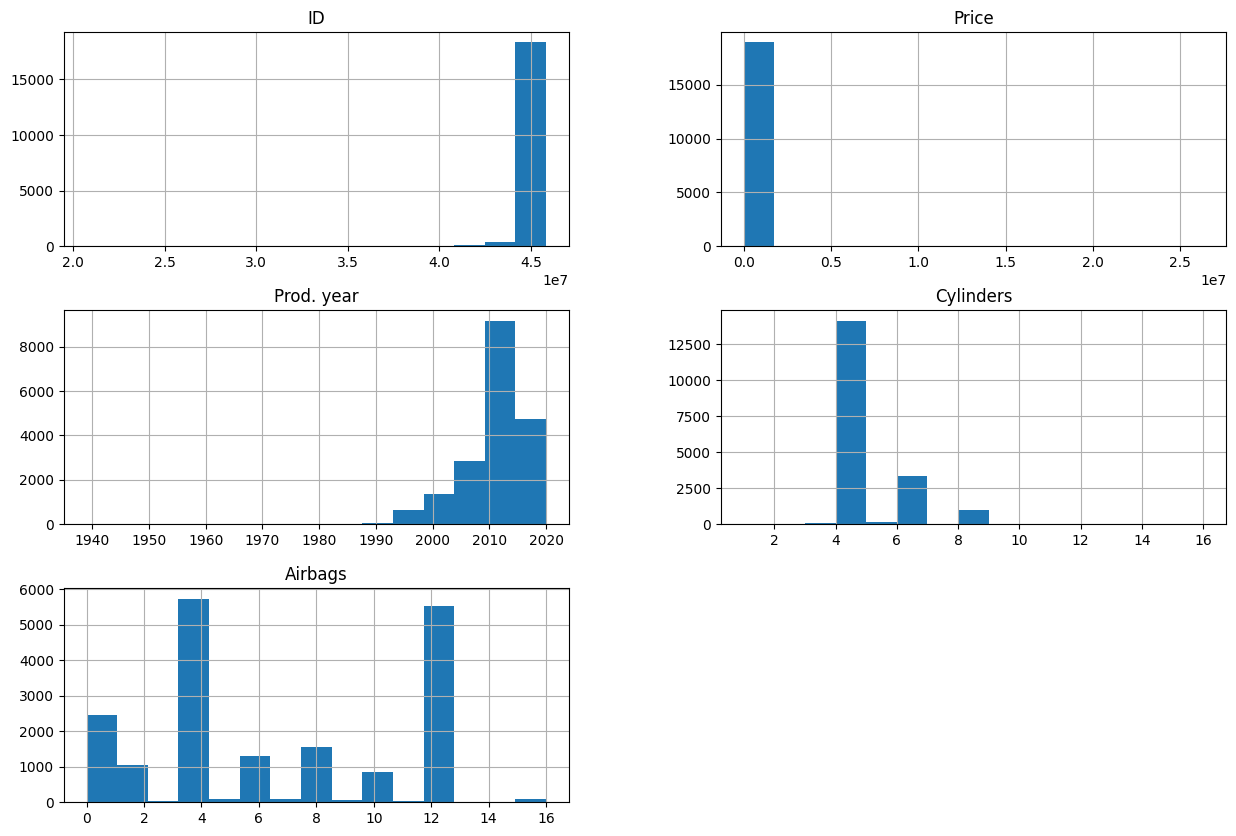

In [14]:
df.hist(bins= 15, figsize=(15,10))
plt.show()

In [15]:
topCars = df['Manufacturer'].value_counts().sort_values(ascending=False)[:15]
topCars

Manufacturer
HYUNDAI          3729
TOYOTA           3606
MERCEDES-BENZ    2043
FORD             1088
CHEVROLET        1047
BMW              1036
HONDA             960
LEXUS             927
NISSAN            645
VOLKSWAGEN        571
SSANGYONG         439
KIA               417
OPEL              396
MITSUBISHI        288
SUBARU            274
Name: count, dtype: int64

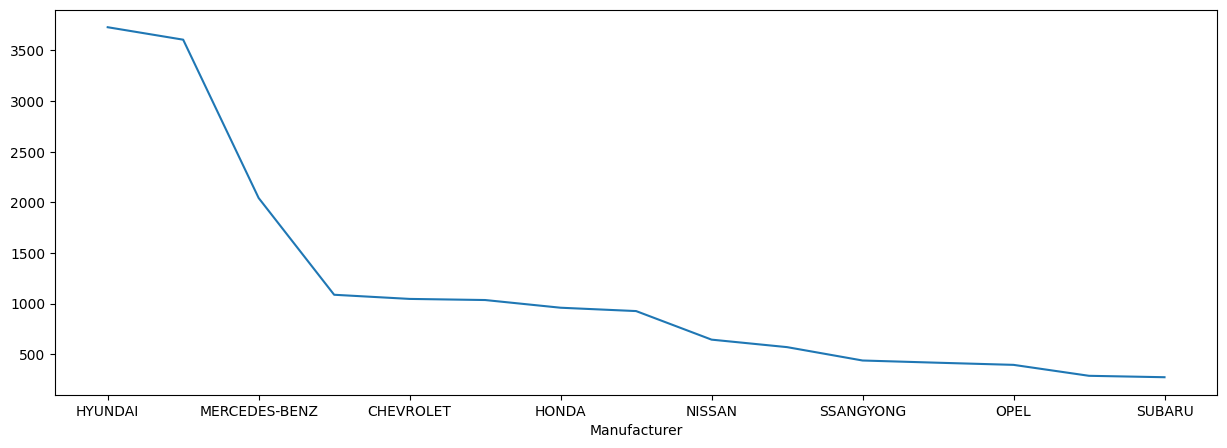

In [16]:
topCars.plot(figsize=(15,5))
plt.show()

In [17]:
topTenPrices = [df[df['Manufacturer'] == i]['Price'].mean()   for i in list(topCars.index)]
topTenPrices   

[np.float64(22306.00080450523),
 np.float64(14302.447864669994),
 np.float64(18590.331375428294),
 np.float64(15411.85018382353),
 np.float64(14894.873925501433),
 np.float64(20609.468146718147),
 np.float64(14162.073958333332),
 np.float64(20052.594390507013),
 np.float64(9835.84031007752),
 np.float64(11471.77408056042),
 np.float64(30921.858769931663),
 np.float64(15254.503597122302),
 np.float64(73474.89393939394),
 np.float64(13182.28125),
 np.float64(10009.43795620438)]

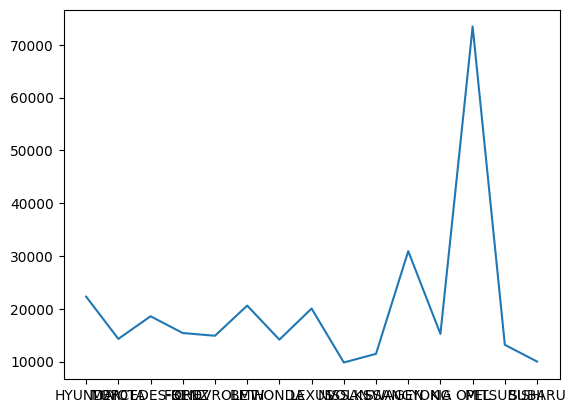

In [18]:
plt.plot(topCars.index, topTenPrices)
plt.show()

<Axes: >

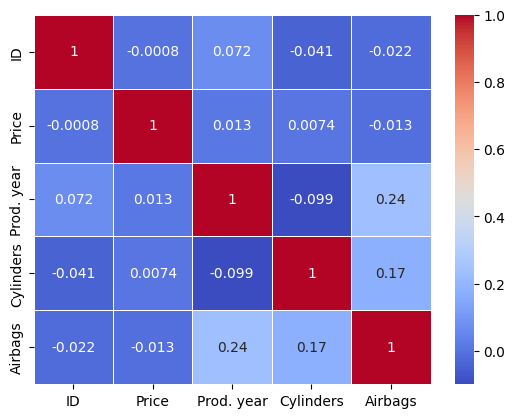

In [19]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm', annot=True, linewidths=0.5)

In [20]:
objectData = df.select_dtypes(include='object')
objectData.head()

,Levy,Manufacturer,Model,Category,Leather interior,Fuel type,Engine volume,Mileage,Gear box type,Drive wheels,Doors,Wheel,Color
0,1399,LEXUS,RX 450,Jeep,Yes,Hybrid,3.5,186005 km,Automatic,4x4,04-May,Left wheel,Silver
1,1018,CHEVROLET,Equinox,Jeep,No,Petrol,3,192000 km,Tiptronic,4x4,04-May,Left wheel,Black
2,-,HONDA,FIT,Hatchback,No,Petrol,1.3,200000 km,Variator,Front,04-May,Right-hand drive,Black
3,862,FORD,Escape,Jeep,Yes,Hybrid,2.5,168966 km,Automatic,4x4,04-May,Left wheel,White
4,446,HONDA,FIT,Hatchback,Yes,Petrol,1.3,91901 km,Automatic,Front,04-May,Left wheel,Silver


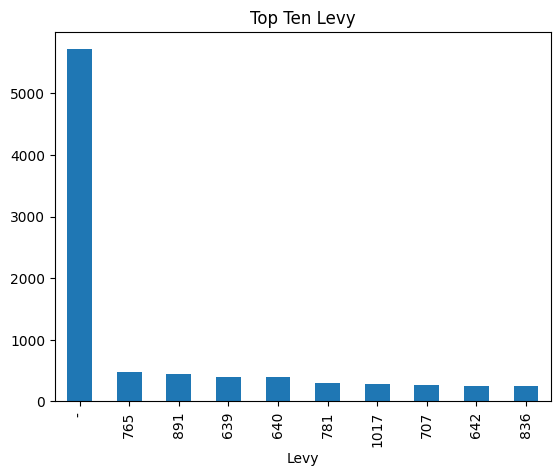

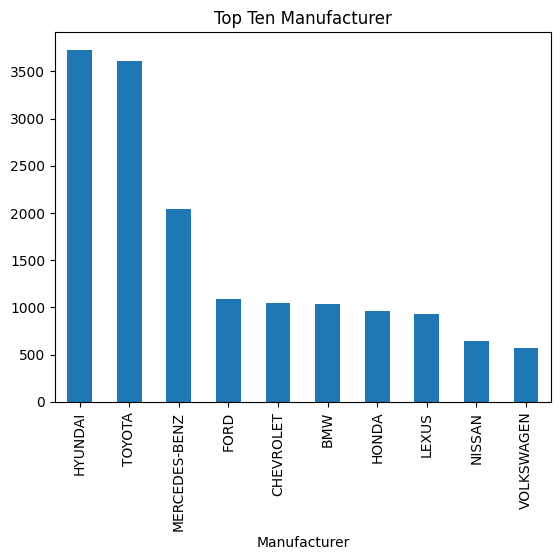

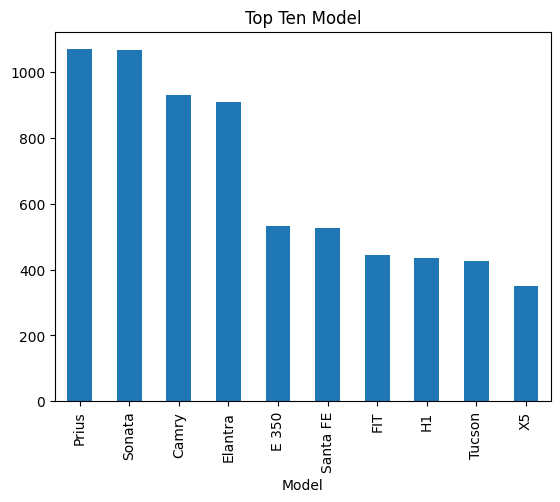

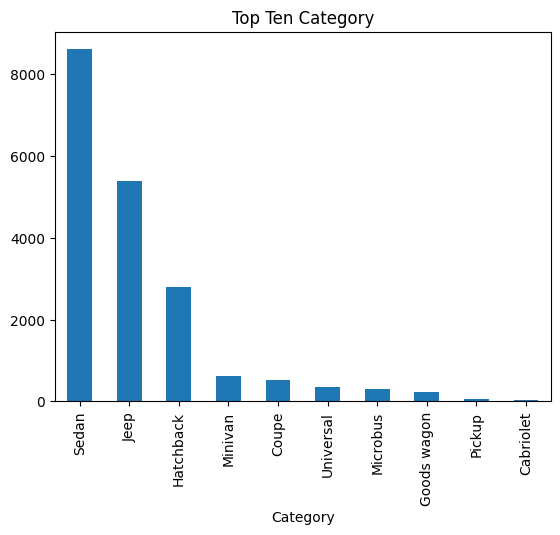

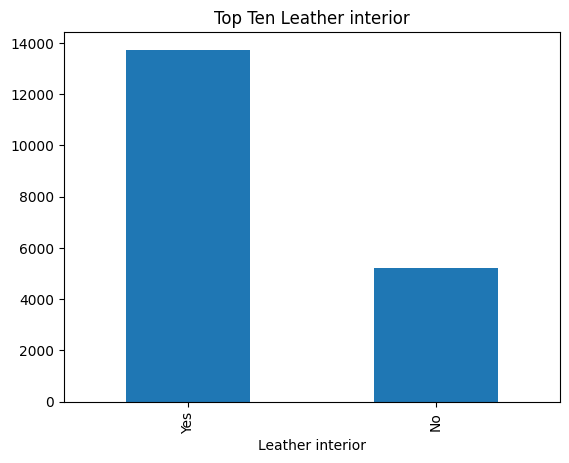

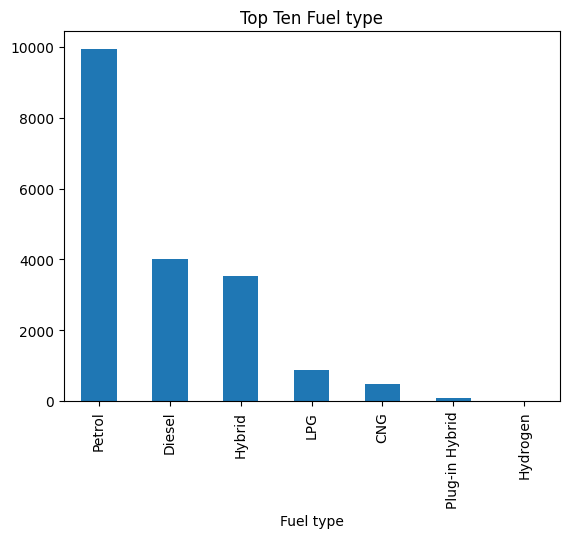

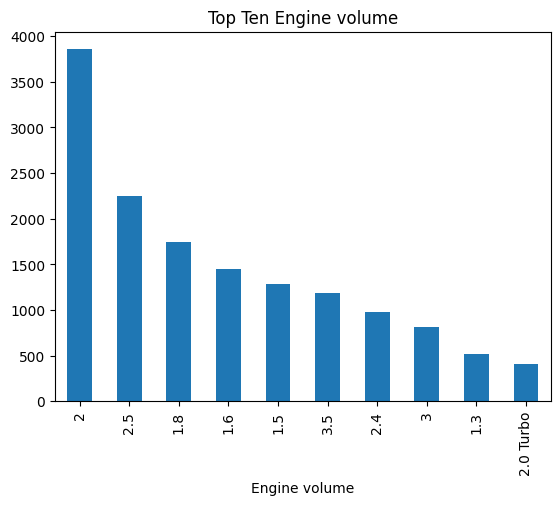

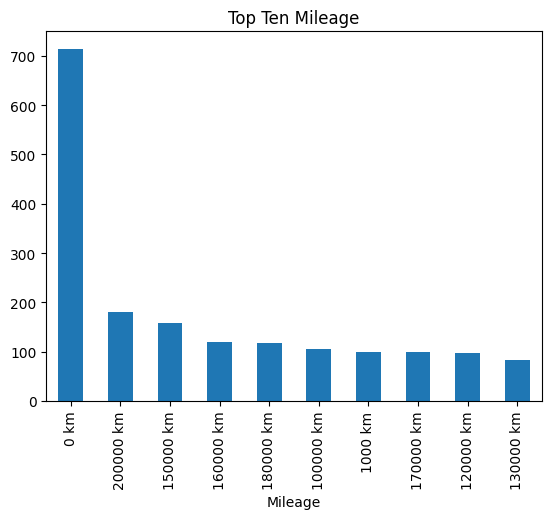

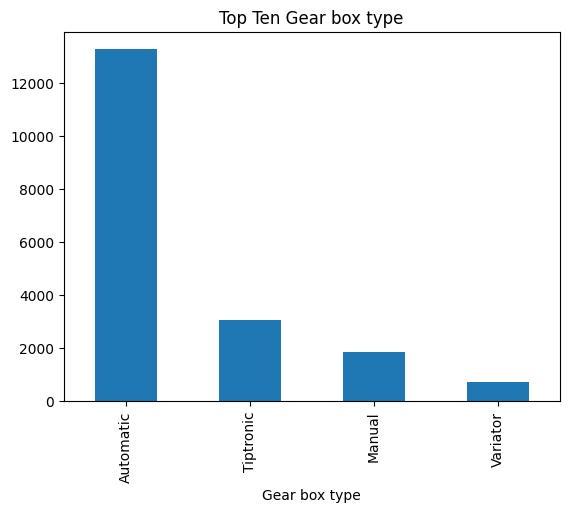

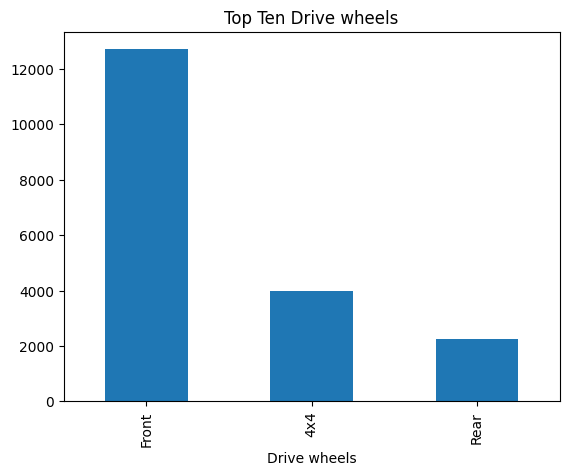

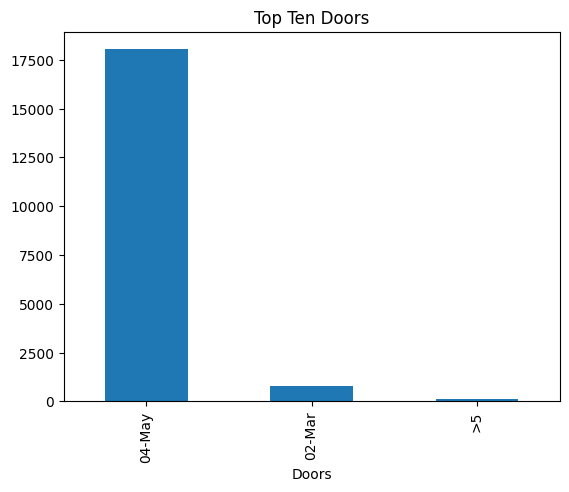

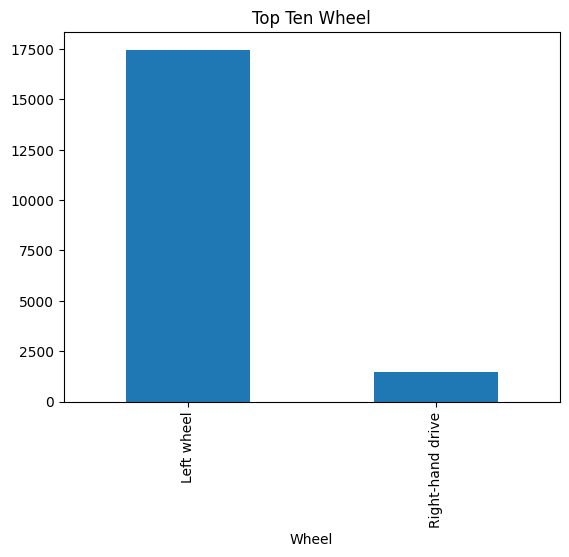

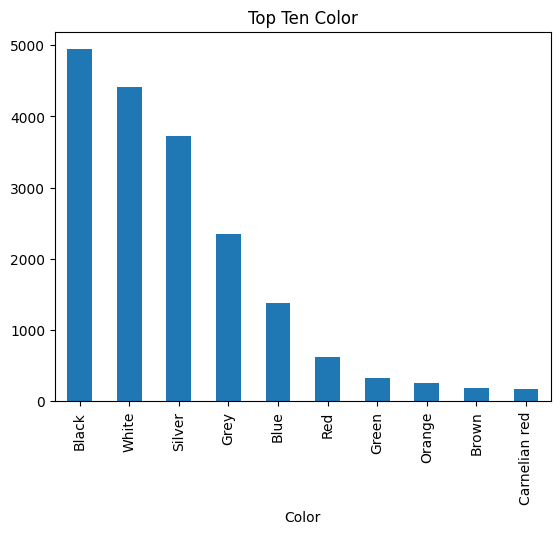

In [21]:
for i in objectData:
    plt.Figure(figsize=(10,5))
    topTen = df[i].value_counts()[:10]
    topTen.plot(kind='bar')
    plt.title(r'Top Ten' + ' ' + i)
    plt.show()

In [22]:
df = df.drop(['ID', 'Doors'], axis=1)
df.head()

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Wheel,Color,Airbags
0,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,Left wheel,Silver,12
1,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,Left wheel,Black,8
2,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,Right-hand drive,Black,2
3,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,Left wheel,White,0
4,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,Left wheel,Silver,4


In [23]:
import datetime
myDateTime = datetime.datetime.now()
df['Car Age'] = myDateTime.year - df['Prod. year']  
df.head()

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Wheel,Color,Airbags,Car Age
0,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,Left wheel,Silver,12,16
1,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,Left wheel,Black,8,15
2,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,Right-hand drive,Black,2,20
3,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,Left wheel,White,0,15
4,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,Left wheel,Silver,4,12


In [24]:
df = df.drop('Prod. year' ,axis=1)

In [25]:
df['Mileage'] = df['Mileage'].str.replace('km', '')
df['Mileage'] = df['Mileage'].astype(float) 

df['Engine volume'] = df['Engine volume'].str.replace('Turbo', '')
df['Engine volume'] = df['Engine volume'].astype(float)


df.info()

<class 'pandas.DataFrame'>
Index: 18924 entries, 0 to 19236
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             18924 non-null  int64  
 1   Levy              18924 non-null  str    
 2   Manufacturer      18924 non-null  str    
 3   Model             18924 non-null  str    
 4   Category          18924 non-null  str    
 5   Leather interior  18924 non-null  str    
 6   Fuel type         18924 non-null  str    
 7   Engine volume     18924 non-null  float64
 8   Mileage           18924 non-null  float64
 9   Cylinders         18924 non-null  float64
 10  Gear box type     18924 non-null  str    
 11  Drive wheels      18924 non-null  str    
 12  Wheel             18924 non-null  str    
 13  Color             18924 non-null  str    
 14  Airbags           18924 non-null  int64  
 15  Car Age           18924 non-null  int64  
dtypes: float64(3), int64(3), str(10)
memory usage: 2.5 MB


In [26]:
data_numeric = df.select_dtypes(exclude='object')

for i in data_numeric:
    q1 = df[i].quantile(0.25)
    q3 = df[i].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    outlier = ((data_numeric[i]>high) | (data_numeric[i]<low)).sum()
    total = data_numeric[i].shape[0]
    print(f'Total outlier in {i} = {outlier} - {round(100*(outlier)/total,2)}')
    if outlier > 0:
        df = df.loc[(df[i] <= high )& (df[i] >= low)]

Total outlier in Price = 1055 - 5.57
Total outlier in Engine volume = 1358 - 7.18
Total outlier in Mileage = 646 - 3.41
Total outlier in Cylinders = 4765 - 25.18
Total outlier in Airbags = 0 - 0.0
Total outlier in Car Age = 1777 - 9.39


In [27]:

dObject = df.select_dtypes(include='object')
dNumeric = df.select_dtypes(exclude='object')

In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in dObject.columns:
    dObject[col] = le.fit_transform(dObject[col])

In [29]:
df = pd.concat([dObject,dNumeric], axis=1)

In [30]:
df.info()
df.head()

<class 'pandas.DataFrame'>
Index: 11820 entries, 2 to 19236
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Levy              11820 non-null  int64  
 1   Manufacturer      11820 non-null  int64  
 2   Model             11820 non-null  int64  
 3   Category          11820 non-null  int64  
 4   Leather interior  11820 non-null  int64  
 5   Fuel type         11820 non-null  int64  
 6   Gear box type     11820 non-null  int64  
 7   Drive wheels      11820 non-null  int64  
 8   Wheel             11820 non-null  int64  
 9   Color             11820 non-null  int64  
 10  Price             11820 non-null  int64  
 11  Engine volume     11820 non-null  float64
 12  Mileage           11820 non-null  float64
 13  Cylinders         11820 non-null  float64
 14  Airbags           11820 non-null  int64  
 15  Car Age           11820 non-null  int64  
dtypes: float64(3), int64(13)
memory usage: 1.5 MB


,Levy,Manufacturer,Model,Category,Leather interior,Fuel type,Gear box type,Drive wheels,Wheel,Color,Price,Engine volume,Mileage,Cylinders,Airbags,Car Age
2,0,16,346,3,0,4,3,1,1,1,8467,1.3,200000.0,4.0,2,20
3,291,12,333,4,1,2,0,0,0,14,3607,2.5,168966.0,4.0,0,15
4,168,16,346,3,1,4,0,1,0,12,11726,1.3,91901.0,4.0,4,12
5,304,17,681,4,1,1,0,1,0,14,39493,2.0,160931.0,4.0,4,10
6,264,43,614,3,1,2,0,1,0,14,1803,1.8,258909.0,4.0,12,16


In [31]:
# ---------------------------------------   Model Training ---------------------------------------------


X = df.drop('Price', axis=1)
Y = df['Price']

X_train, x_test, Y_train, y_test = train_test_split(X, Y, random_state=42, test_size=25)

In [32]:
algorithm = ['LinearRegression', 'DecisionTreeClassifier', 'RandomForestClassifier', 'DecisionTreeRegressor', 'RandomForestRegressor']
r_2 =[]
Rmse =[]

In [33]:
def models(model):

    model.fit(X_train, Y_train)

    y_predict = model.predict(x_test) 

    r2 = r2_score(y_test, y_predict)
    rmse = np.sqrt(mean_squared_error(y_test, y_predict))
    


    r_2.append(r2)
    Rmse.append(rmse)

    
    print(model)
    print(f'r2_score = {r2}')
    print(f'mean_squared_error =\n {rmse}\n')

In [34]:
model1 = LinearRegression()
model2 = DecisionTreeClassifier(max_depth=2000)
model3 = RandomForestClassifier(max_depth=1000)
model4 = DecisionTreeRegressor(max_depth=2000)
model5 = RandomForestRegressor(max_depth=2000)


In [35]:
models(model1)
models(model2)
models(model3)
models(model4)
models(model5)

LinearRegression()
r2_score = 0.16865683396225706
mean_squared_error =
 10938.030565653695

DecisionTreeClassifier(max_depth=2000)
r2_score = 0.7838654844698211
mean_squared_error =
 5577.133374772384

RandomForestClassifier(max_depth=1000)
r2_score = 0.8104991013494829
mean_squared_error =
 5222.213270252375

DecisionTreeRegressor(max_depth=2000)
r2_score = 0.8280348825378421
mean_squared_error =
 4974.725793448318

RandomForestRegressor(max_depth=2000)
r2_score = 0.9029018776236871
mean_squared_error =
 3738.1298484768945



In [36]:
pd.DataFrame({'Alogorithm':algorithm, 'R2_Score': r_2, 'RMSE': Rmse})

,Alogorithm,R2_Score,RMSE
0,LinearRegression,0.168657,10938.030566
1,DecisionTreeClassifier,0.783865,5577.133375
2,RandomForestClassifier,0.810499,5222.213270
3,DecisionTreeRegressor,0.828035,4974.725793
4,RandomForestRegressor,0.902902,3738.129848


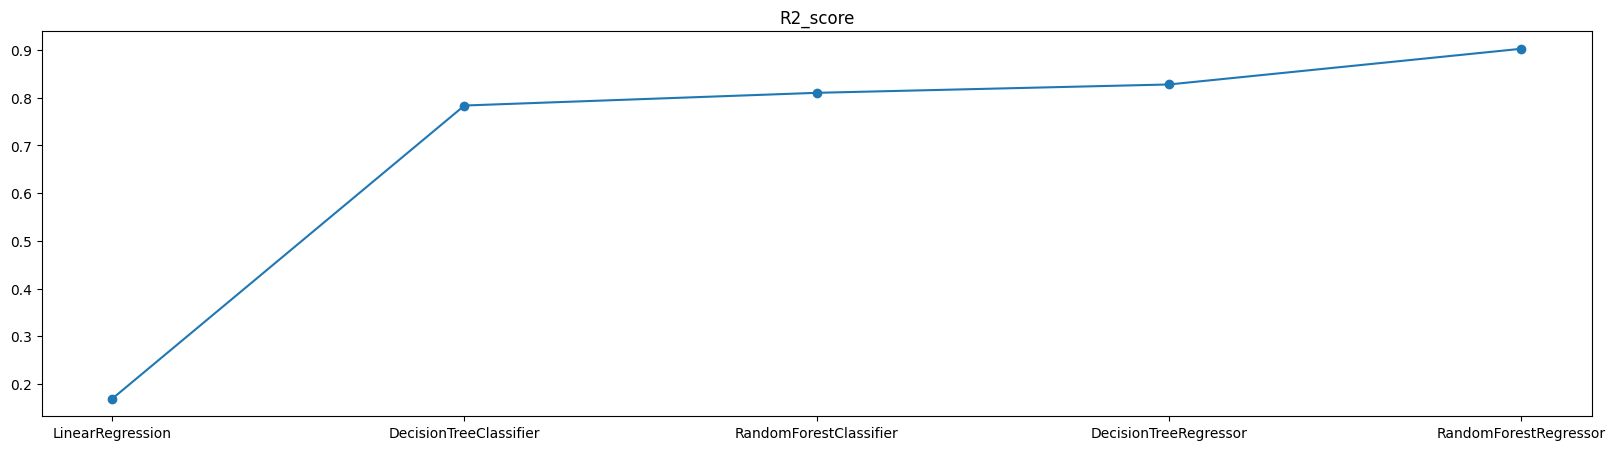

In [37]:
plt.subplots(figsize=(20,5))
plt.plot(algorithm, r_2, marker='o')
plt.title('R2_score')
plt.show()

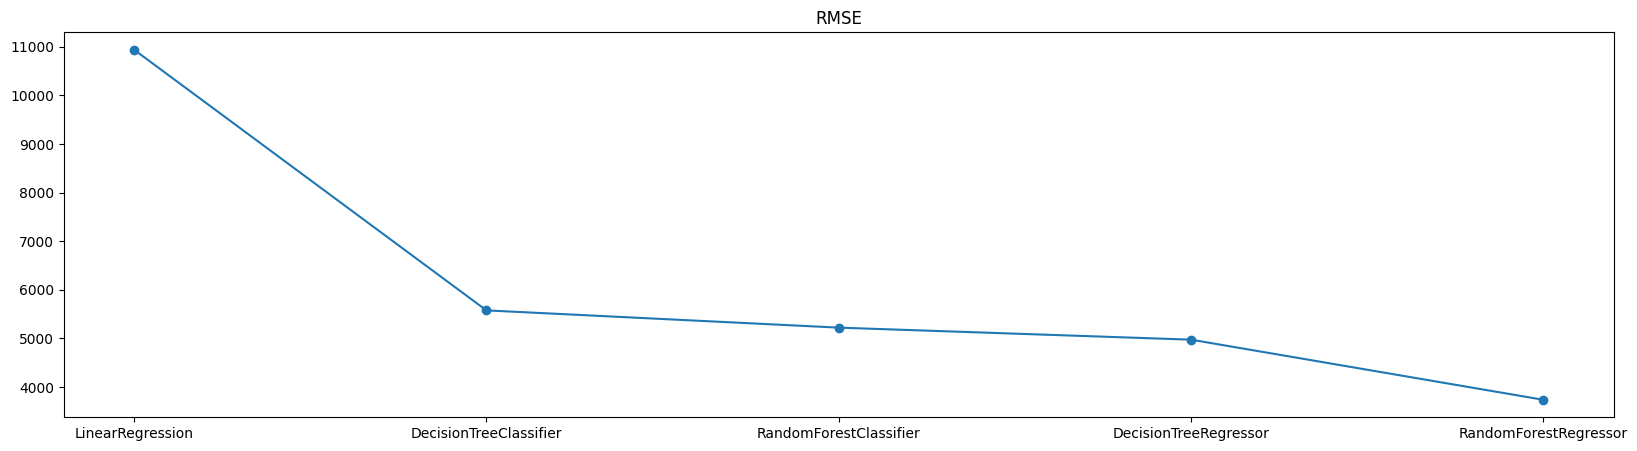

In [38]:
plt.subplots(figsize=(20,5))
plt.plot(algorithm, Rmse, marker='o')
plt.title('RMSE')
plt.show()

In [39]:
import pickle
Cars_Price = 'Cars_Prediction.sav'

In [40]:
pickle.dump(model5,open(Cars_Price,'wb'))


In [41]:
df['Manufacturer'].unique()

array([16, 12, 17, 43, 27, 45, 35, 31,  6, 41,  9,  3, 21, 30, 40, 26, 14,
       11, 42, 24, 32,  2,  8, 29, 10, 20,  0, 44, 19, 39,  7, 25,  4, 33,
       47, 15, 23,  5, 38, 18, 34, 22, 28, 36, 46,  1, 37, 13])

In [42]:
df['Category'].unique()


array([3, 4, 8, 9, 6, 0, 1, 5, 2, 7])

In [43]:
df['Leather interior'].unique()



array([0, 1])

In [44]:
df['Fuel type'].unique()


array([4, 2, 1, 5, 3, 0])

In [45]:
df['Gear box type'].unique()


array([3, 0, 2, 1])

In [46]:
df['Drive wheels'].unique()


array([1, 0, 2])

In [47]:
df['Wheel'].unique()

array([1, 0])

In [48]:
df['Color'].unique()

array([ 1, 14, 12,  7,  2, 13, 11,  6, 15,  3,  5,  0,  8,  4, 10,  9])

In [49]:
df['Engine volume'].unique()

array([1.3, 2.5, 2. , 1.8, 2.4, 1.6, 2.2, 1.5, 1.4, 2.3, 1.2, 1.7, 2.9,
       1.9, 3.5, 2.1, 2.7, 1. , 0.8, 3. , 3.3, 2.8, 3.2, 1.1])

In [50]:
df['Airbags'].unique()

array([ 2,  0,  4, 12,  8, 10,  6,  1, 16,  7,  9,  5, 11,  3, 14, 15, 13])

In [52]:
df['Model'].unique()

array([346, 333, 681, 614, 695, 167, 312, 194, 294, 428, 467, 621,  99,
       335, 226, 543, 300, 482, 273, 395, 773,  66, 767, 213, 554, 833,
       269, 575, 382, 502,  37, 414, 723, 376, 609,  94, 497,  63, 687,
       650, 809, 740, 443,  40, 327,  67, 658, 217,   2, 145, 807, 755,
       775, 343, 445, 425, 175, 781, 655, 692, 593, 119, 223, 184, 112,
       245, 670, 409, 689, 748, 152,  91, 674, 652, 303, 263, 118, 521,
       232, 579, 199, 523, 459,  98, 795, 412, 231, 153, 656, 405, 124,
       104, 569, 690, 507, 331, 805,  80, 495,  30, 328, 158, 818, 659,
       109, 249, 171, 370, 239, 235,  74, 254, 647, 568, 499, 460, 373,
       532, 535, 684,  25, 557, 718, 527, 435, 707, 322, 117, 307, 678,
        51, 279, 258, 246, 671,  83, 646,  86, 426, 442, 285, 185,  89,
       404, 466, 238, 758, 830, 105, 547, 634, 715,   3, 305, 719, 789,
       365, 216, 734, 284, 736, 741,  73, 843, 448, 275, 450,   8, 757,
       580, 610, 743, 224, 838,  16, 829, 207, 498, 565, 536, 46